# SR3 RV Lab — Framework 3: vol vs realized (gamma / theta)

**RV class: C — implied vs delivered on the same contract.**

The only framework where the futures market and the options market disagree
about something neither put-call parity nor the forward can pin: the *size* of
the moves the future will actually make. The trade is an ATM straddle at a
fixed listed strike, delta-hedged **daily on the futures settle** with the
delta observed the previous close.

Signals tested (all premium-native):

* `IV - RV`: listed ATM normal vol minus trailing realized bp vol of the same
  contract's own futures rate.
* `always short`: the unconditional short-gamma benchmark. Every rule has to
  beat this, not zero — the vol-selling literature's own finding is that the
  unconditional short is hard to improve on.
* `vol-return momentum`: sign of the trailing P&L of the always-short program
  (self-referential; no external data).

### The trap this notebook has to avoid

SR3 settles on **compounded SOFR over the reference quarter**. Once the quarter
starts accruing, part of the settlement is already known, so the front
contract's implied vol falls for a purely mechanical reason that has nothing to
do with risk premium. Any IV-vs-RV signal that ranks contracts by vol level
will find enormous fake alpha in the front contract. The cross-sectional work
below is therefore run on contracts with **time to expiry above a floor**, and
the time-to-expiry sensitivity is reported.

In [1]:
CONFIG = dict(
    rv_window=21,             # trailing realized-vol window (business days)
    min_tte=0.15,             # drop contracts inside ~8 weeks of expiry
    min_oi=100,
    contracts_per_leg=100,
    cost_bp=2.5,
    future_leg_bp=0.25,       # charged on every re-hedge, on the traded delta
    rehedge_bands=(0.0, 0.10, 0.25),
    mas=(1, 5, 10),
    zscore_windows=(60, 120),
    entry_zs=(1.0, 1.5, 2.0),
    exits=("t5", "t10", "t20"),
    directions=("fade", "momentum"),
)
CONFIG

{'rv_window': 21,
 'min_tte': 0.15,
 'min_oi': 100,
 'contracts_per_leg': 100,
 'cost_bp': 2.5,
 'future_leg_bp': 0.25,
 'rehedge_bands': (0.0, 0.1, 0.25),
 'mas': (1, 5, 10),
 'zscore_windows': (60, 120),
 'entry_zs': (1.0, 1.5, 2.0),
 'exits': ('t5', 't10', 't20'),
 'directions': ('fade', 'momentum')}

In [2]:
import dataclasses
import sys
from pathlib import Path

import numpy as np
import pandas as pd

sys.path.append("../../")
sys.path.append(str(Path.cwd()))

import matplotlib
if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt

from sfr_rv_lab_common import (
    LabConfig, config_from_row, cost_block, header_block, league_row, load_lab,
    run_framework, three_panel_equity,
)
from RVUtils.SFRRVLab import (
    Leg, Structure, add_event_distance, atm_premium_panel,
    constant_maturity_slots, realized_vol_bp, run_backtest,
)

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 60)

lab = load_lab()
quotes, contracts = lab["quotes"], lab["contracts"]

parity completion: 199319 listed quotes + 191259 reconstructed (96.0%) so ITM legs stay marked


## The ATM straddle panel and the mechanical-decay check

In [3]:
atm = atm_premium_panel(quotes, contracts)
atm = atm.merge(constant_maturity_slots(contracts)[
    ["as_of", "symbol", "tte", "cm_slot", "expiry_date"]],
    on=["as_of", "symbol"], how="left")
print(f"ATM straddle rows: {len(atm)}  symbols: {atm['symbol'].nunique()}")

rv = []
for sym, sub in contracts.sort_values("as_of").groupby("symbol"):
    s = sub.set_index("as_of")["forward_rate"]
    rv.append(pd.DataFrame({"as_of": s.index, "symbol": sym,
                            "rv_bp": realized_vol_bp(s, CONFIG["rv_window"])}))
rv = pd.concat(rv, ignore_index=True)
atm = atm.merge(rv, on=["as_of", "symbol"], how="left")
atm["vrp_bp"] = atm["atm_iv_bp"] - atm["rv_bp"]
atm = add_event_distance(atm)
print(atm.groupby("cm_slot")[["tte", "atm_iv_bp", "rv_bp", "vrp_bp"]]
      .median().round(2).to_string())

ATM straddle rows: 4030  symbols: 14
          tte  atm_iv_bp  rv_bp  vrp_bp
cm_slot                                
1        0.17      50.89  47.13    2.97
2        0.41      68.93  69.46   -0.53
3        0.66      83.76  80.23    1.85
4        0.91      95.21  88.43    5.29
5        1.16     101.35  91.64    8.89
6        1.41     104.84  91.20   12.87
7        1.65     102.99  87.32   14.67
8        1.87     100.89  81.78   14.58


The mechanical decay is visible directly: ATM vol against time to expiry. The
front contract's collapse is the accrued-fixings effect, not cheap options.

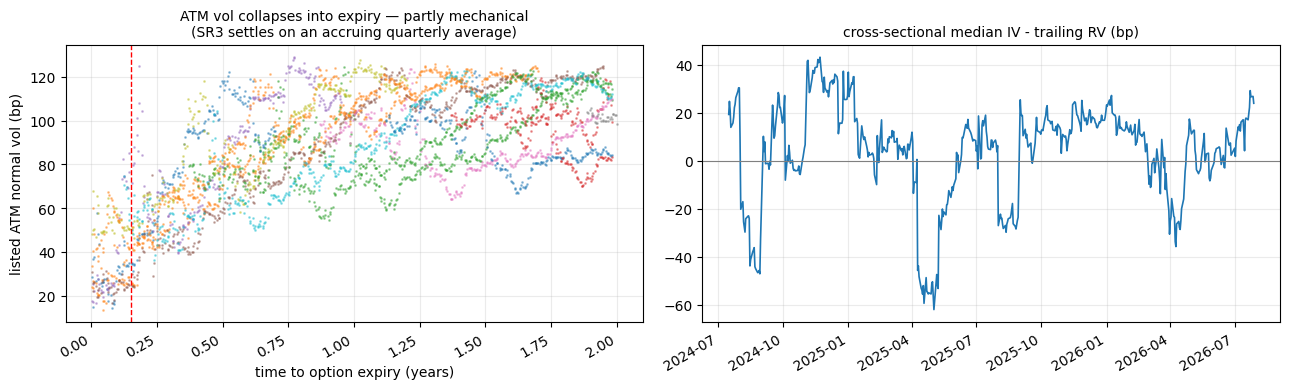

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for sym, sub in atm.groupby("symbol"):
    axes[0].plot(sub["tte"], sub["atm_iv_bp"], ".", ms=2, alpha=0.4, label=sym)
axes[0].set_xlabel("time to option expiry (years)")
axes[0].set_ylabel("listed ATM normal vol (bp)")
axes[0].set_title("ATM vol collapses into expiry — partly mechanical\n"
                  "(SR3 settles on an accruing quarterly average)", fontsize=10)
axes[0].axvline(CONFIG["min_tte"], color="red", ls="--", lw=1)
axes[0].grid(alpha=0.25)
axes[1].plot(atm.groupby("as_of")["vrp_bp"].median(), lw=1.2)
axes[1].axhline(0, color="grey", lw=0.8)
axes[1].set_title("cross-sectional median IV - trailing RV (bp)", fontsize=10)
axes[1].grid(alpha=0.25)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

In [5]:
panel = atm[atm["tte"] >= CONFIG["min_tte"]].copy()
panel = panel.dropna(subset=["vrp_bp"])
print(f"after the time-to-expiry floor: {len(panel)} rows, "
      f"{panel['symbol'].nunique()} symbols")
print(f"median VRP {panel['vrp_bp'].median():+.1f}bp   "
      f"share IV>RV {(panel['vrp_bp'] > 0).mean():.1%}")

after the time-to-expiry floor: 3657 rows, 14 symbols
median VRP +7.1bp   share IV>RV 65.2%


## The tradeable package

One ATM straddle per contract at the listed strike fixed on the execution
date, delta-hedged daily by the engine. `direction=+1` is LONG the straddle
(long gamma, paying theta); `fade` on a rich IV-minus-RV signal therefore sells
gamma, which is the direction the literature says carries the premium.

In [6]:
STRIKE = panel.set_index(["symbol", "as_of"])["atm_strike"].sort_index()


def builder(key, exec_date, direction):
    try:
        k = float(STRIKE.loc[(key, exec_date)])
    except (KeyError, TypeError):
        return None
    return Structure((Leg("option", key, 1.0, "C", k),
                      Leg("option", key, 1.0, "P", k)),
                     label=f"straddle {key}@{k:g}")


BASE = LabConfig(lag=1, round_trip_cost_bp=CONFIG["cost_bp"],
                 contracts_per_leg=CONFIG["contracts_per_leg"],
                 delta_hedge="daily", future_leg_bp=CONFIG["future_leg_bp"],
                 rehedge_band=0.0)

sig_vrp = panel.rename(columns={"symbol": "key"})[
    ["key", "as_of", "vrp_bp", "tte", "days_to_fomc"]].copy()
sig_vrp["signal"] = sig_vrp["vrp_bp"]
sig_vrp["gate"] = True

GRID = {"direction": list(CONFIG["directions"]), "ma": list(CONFIG["mas"]),
        "zscore_window": list(CONFIG["zscore_windows"]),
        "entry_min_zscore": list(CONFIG["entry_zs"]),
        "exit_style": list(CONFIG["exits"])}
PARAMS = ["direction", "ma", "zscore_window", "entry_min_zscore", "exit_style"]

## Benchmark first: the unconditional short-gamma program

Sell every contract's ATM straddle every N days, delta-hedge daily, hold to the
horizon. No signal at all. This is the number every rule below must beat.

In [7]:
bench_rows = []
for hold in ("t5", "t10", "t20"):
    for d in ("short", "long"):
        # entry_rule='always' holds ONE side unconditionally. Driving a
        # "benchmark" off a z-score instead would flip the side from bar to bar,
        # which is not a program at all.
        cfg = dataclasses.replace(
            BASE, entry_rule="always", exit_style=hold, entry_every=5,
            direction="fade" if d == "short" else "momentum")
        r = run_backtest(cfg, signals=sig_vrp, book=lab["book"], builder=builder)
        bench_rows.append({"side": d, "hold": hold, **{
            k: r.metrics[k] for k in ("n_trades", "hit_rate", "avg_net_bp",
                                      "total_net_bp", "total_net_usd", "sharpe",
                                      "max_dd_bp")}})
bench = pd.DataFrame(bench_rows).round(3)
print("UNCONDITIONAL GAMMA PROGRAM (delta-hedged daily, no signal)")
print(bench.to_string(index=False))
print("\nA positive 'short' row is the variance risk premium net of hedging "
      "costs; every signal below must beat it, not zero.")

UNCONDITIONAL GAMMA PROGRAM (delta-hedged daily, no signal)
 side hold  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp
short   t5       365     0.192      -3.085     -1126.018    -2815044.75  -4.165  -1132.843
 long   t5       365     0.233      -2.059      -751.629    -1879071.75  -3.011   -792.041
short  t10       247     0.291      -2.551      -630.002    -1575006.25  -2.102   -636.827
 long  t10       247     0.275      -2.704      -667.777    -1669441.75  -2.323   -672.325
short  t20       152     0.441      -1.594      -242.350     -605874.75  -0.733   -340.249
 long  t20       152     0.263      -3.846      -584.650    -1461624.50  -1.818   -621.245

A positive 'short' row is the variance risk premium net of hedging costs; every signal below must beat it, not zero.


## Signal 1 — IV minus trailing realized vol

  25/108 configs


  50/108 configs


  75/108 configs


  100/108 configs



=== 3. Gamma/theta (IV-RV) — grid ===
  108 configs | median -201.42bp | IQR [-348.98, -114.76] | 8% net-positive | best +64.62bp

  top rows (SELECTION-INFLATED — read the distribution above first):
direction  ma  zscore_window  entry_min_zscore exit_style  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp
     fade   1             60               2.0        t20        47     0.617       1.375        64.616      161538.75   0.455   -159.870
     fade   1             60               1.5        t20        71     0.563       0.744        52.809      132023.00   0.243   -175.454
     fade   1            120               2.0        t20        28     0.464       1.597        44.727      111818.25   0.355   -188.425
     fade   5            120               2.0        t20        21     0.333       1.823        38.283       95707.25   0.432   -156.796
     fade   5             60               1.5        t20        60     0.500       0.493        29.591      

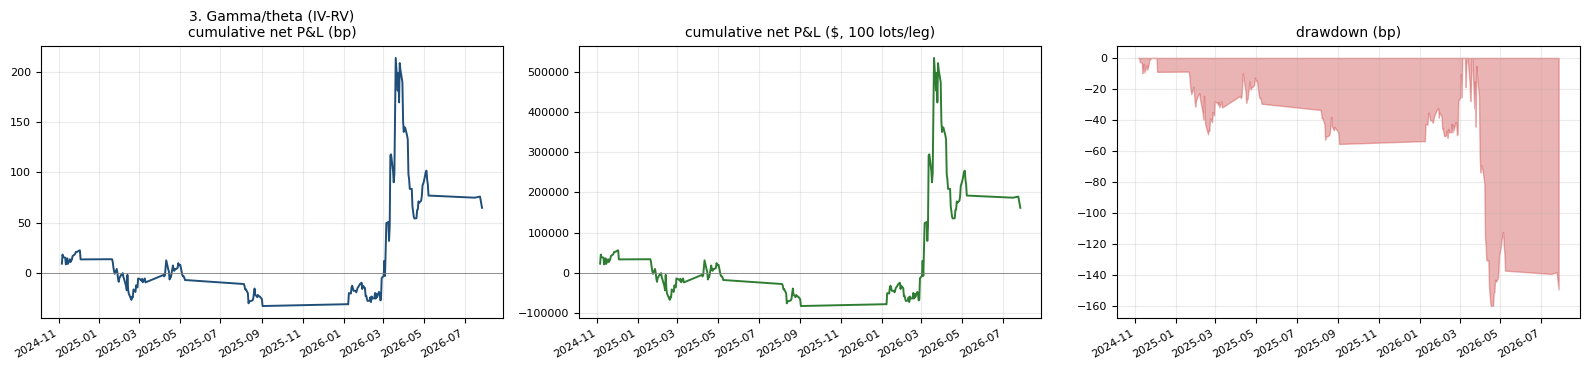


TRADE LOG (first rows)
   key  dir               structure signal_date      entry       exit  days   z_in  gross_bp  cost_bp   net_bp   net_usd  stale_frac  pkg_contracts exit_reason
SFRH26   -1   straddle SFRH26@96.25  2024-11-04 2024-11-05 2024-12-04    20  2.031    4.6870      2.5   2.1870   5467.47         0.0            2.0        time
SFRZ25   -1   straddle SFRZ25@96.25  2024-11-04 2024-11-05 2024-12-04    20  2.035    4.9735      2.5   2.4735   6183.86         0.0            2.0        time
SFRM25   -1  straddle SFRM25@96.125  2024-11-04 2024-11-05 2024-12-04    20  2.026    7.3962      2.5   4.8962  12240.58         0.0            2.0        time
SFRU25   -1 straddle SFRU25@96.1875  2024-11-04 2024-11-05 2024-12-04    20  2.077    6.2097      2.5   3.7097   9274.16         0.0            2.0        time
SFRM26    1      straddle SFRM26@96  2025-01-15 2025-01-16 2025-02-14    20 -2.133  -10.2712      2.5 -12.7712 -31927.96         0.0            2.0        time
SFRU26    1     

signal_source  lag  n_trades  total_gross_bp  total_net_bp  sharpe  hit_rate
       listed    0        47         214.217        96.717   0.692     0.574
       listed    1        47         182.116        64.616   0.455     0.617
same-bar (lag 0) gross inflation: 15.0%

  cost curve (round-trip bp charged on the package):
 round_trip_bp  n  total_net_bp  avg_net_bp  hit_rate  total_net_usd
           0.0 47       182.116       3.875     0.766      455288.75
           0.5 47       158.616       3.375     0.681      396538.75
           1.0 47       135.116       2.875     0.660      337788.75
           1.5 47       111.616       2.375     0.617      279038.75
           2.5 47        64.616       1.375     0.617      161538.75
           4.0 47        -5.884      -0.125     0.532      -14711.25

3. Gamma/theta (IV-RV) — median config (not selected)  |  momentum|ma5|w60|z2.0|t10|lag1|every1|dh  |  100 contracts/leg ($2,500/bp)
  1 package = 2 contracts -> position = 200 contracts acro

In [8]:
out_vrp = run_framework(
    "3. Gamma/theta (IV-RV)", signals=sig_vrp, book=lab["book"], builder=builder,
    base=BASE, grid_spec=GRID, params=PARAMS, cls="C",
    note=f"ATM straddle, daily delta hedge, tte>={CONFIG['min_tte']}y, "
         f"RV window {CONFIG['rv_window']}d")

## Re-hedge band sensitivity

The literature's claim is that P&L net of costs is maximised at a *modest*
delta band rather than hedging every day. SR3's futures leg is cheap, so the
optimum should be tighter here — this measures it instead of assuming it.

In [9]:
band_rows = []
for band in CONFIG["rehedge_bands"]:
    cfg = dataclasses.replace(out_vrp["config"], rehedge_band=band)
    r = run_backtest(cfg, signals=sig_vrp, book=lab["book"], builder=builder)
    band_rows.append({"rehedge_band": band, **{
        k: r.metrics[k] for k in ("n_trades", "hit_rate", "avg_net_bp",
                                  "total_net_bp", "total_net_usd", "sharpe",
                                  "max_dd_bp")}})
print(pd.DataFrame(band_rows).round(3).to_string(index=False))

 rehedge_band  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp
         0.00        47     0.617       1.375        64.616      161538.75   0.455   -159.870
         0.10        47     0.638       1.540        72.357      180893.25   0.500   -165.965
         0.25        47     0.532       0.929        43.650      109125.50   0.277   -163.573


## Signal 2 — vol-return momentum (self-referential, no external data)

Take the daily P&L of the always-short program, and go long gamma when its
trailing return is negative. The highest-information-ratio single signal in the
systematic vol literature; here it is rebuilt from this sample's own P&L.

always-short daily P&L: 530 days, total -242.3bp


  25/108 configs


  50/108 configs


  75/108 configs


  100/108 configs



=== 3b. Vol-return momentum — grid ===
  108 configs | median -266.76bp | IQR [-379.84, -148.04] | 0% net-positive | best -31.93bp

  top rows (SELECTION-INFLATED — read the distribution above first):
direction  ma  zscore_window  entry_min_zscore exit_style  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp
     fade  10            120               2.0        t20        28     0.464      -1.140       -31.933      -79832.25  -0.285   -217.608
 momentum   5            120               2.0        t20        26     0.615      -1.629       -42.360     -105901.00  -0.376   -235.669
 momentum   1             60               2.0        t20        58     0.466      -0.828       -48.000     -120000.75  -0.312   -295.379
     fade   1            120               2.0         t5        84     0.369      -0.600       -50.395     -125988.25  -0.550   -158.833
 momentum   1            120               2.0        t20        40     0.450      -1.522       -60.884     

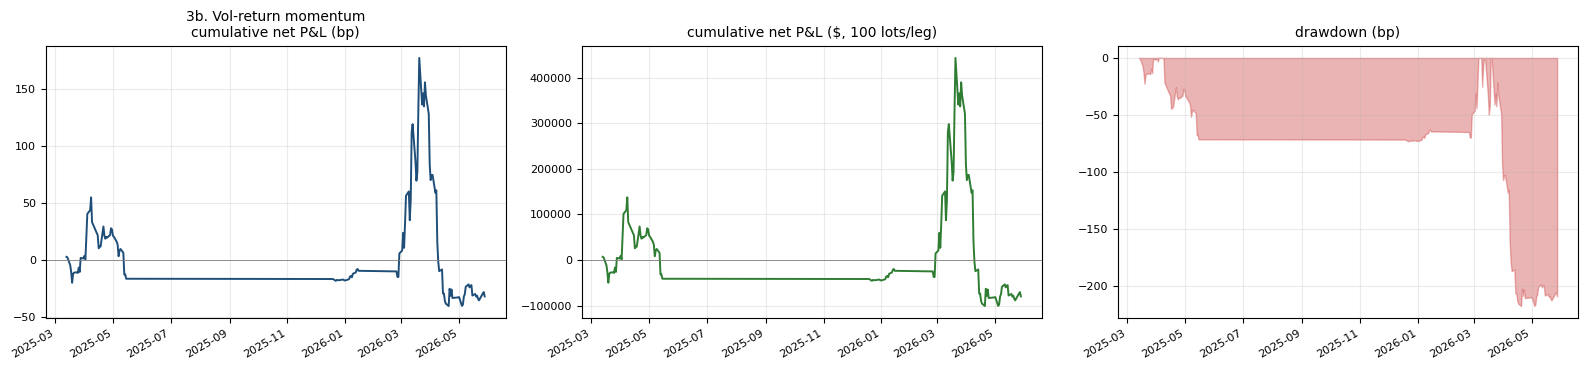


TRADE LOG (first rows)
   key  dir               structure signal_date      entry       exit  days   z_in  gross_bp  cost_bp   net_bp   net_usd  stale_frac  pkg_contracts exit_reason
SFRH26    1  straddle SFRH26@96.375  2025-03-11 2025-03-12 2025-04-09    20 -2.004    7.7128      2.5   5.2128  13032.02         0.0            2.0        time
SFRZ25    1 straddle SFRZ25@96.3125  2025-03-11 2025-03-12 2025-04-09    20 -2.004    8.9330      2.5   6.4330  16082.59         0.0            2.0        time
SFRM26    1    straddle SFRM26@96.5  2025-03-11 2025-03-12 2025-04-09    20 -2.004    9.8389      2.5   7.3389  18347.15         0.0            2.0        time
SFRM25    1 straddle SFRM25@95.9375  2025-03-11 2025-03-12 2025-04-09    20 -2.004    9.0592      2.5   6.5592  16398.01         0.0            2.0        time
SFRU25    1 straddle SFRU25@96.1875  2025-03-11 2025-03-12 2025-04-09    20 -2.004   10.1603      2.5   7.6603  19150.71         0.0            2.0        time
SFRM25    1 stra

signal_source  lag  n_trades  total_gross_bp  total_net_bp  sharpe  hit_rate
       listed    0        28          21.042       -48.958  -0.423     0.429
       listed    1        28          38.067       -31.933  -0.285     0.464
same-bar (lag 0) gross inflation: -80.9%

  cost curve (round-trip bp charged on the package):
 round_trip_bp  n  total_net_bp  avg_net_bp  hit_rate  total_net_usd
           0.0 28        38.067        1.36     0.571       95167.75
           0.5 28        24.067        0.86     0.500       60167.75
           1.0 28        10.067        0.36     0.500       25167.75
           1.5 28        -3.933       -0.14     0.464       -9832.25
           2.5 28       -31.933       -1.14     0.464      -79832.25
           4.0 28       -73.933       -2.64     0.464     -184832.25

3b. Vol-return momentum — median config (not selected)  |  fade|ma1|w60|z1.5|t5|lag1|every1|dh  |  100 contracts/leg ($2,500/bp)
  1 package = 2 contracts -> position = 200 contracts across 

In [10]:
short_cfg = dataclasses.replace(BASE, entry_rule="always", exit_style="t20",
                                entry_every=5, direction="fade")
short_res = run_backtest(short_cfg, signals=sig_vrp, book=lab["book"],
                         builder=builder)
short_daily = short_res.daily_bp.reindex(
    pd.DatetimeIndex(sorted(sig_vrp["as_of"].unique()))).fillna(0.0)
trail = short_daily.rolling(21, min_periods=10).sum()
print(f"always-short daily P&L: {len(short_daily)} days, "
      f"total {short_daily.sum():+.1f}bp")

sig_mom = sig_vrp.copy()
sig_mom["signal"] = sig_mom["as_of"].map(trail)
sig_mom = sig_mom.dropna(subset=["signal"])
out_mom = run_framework(
    "3b. Vol-return momentum", signals=sig_mom, book=lab["book"], builder=builder,
    base=BASE, grid_spec=GRID, params=PARAMS, cls="C",
    note="signal = trailing 21d P&L of the always-short gamma program")

## Signal 3 — cross-sectional vol carry

Rank contracts by VRP within each date and trade the extremes against each
other. Removing the date mean strips out the common vol factor, which is what
makes this the highest-power test in the set.

  25/108 configs


  50/108 configs


  75/108 configs


  100/108 configs



=== 3c. Cross-sectional vol carry — grid ===
  108 configs | median -277.10bp | IQR [-409.50, -192.53] | 0% net-positive | best -46.82bp

  top rows (SELECTION-INFLATED — read the distribution above first):
direction  ma  zscore_window  entry_min_zscore exit_style  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp
     fade  10            120               2.0        t20        40     0.450      -1.171       -46.821     -117052.75  -0.638    -53.844
     fade   5            120               2.0        t20        42     0.405      -1.948       -81.832     -204580.25  -1.039    -89.403
 momentum  10             60               2.0        t20        49     0.367      -1.914       -93.810     -234526.00  -1.293   -146.341
     fade   1            120               1.5        t20        83     0.434      -1.308      -108.525     -271312.50  -0.676   -129.778
     fade   5             60               1.5        t20        84     0.417      -1.363      -114.47

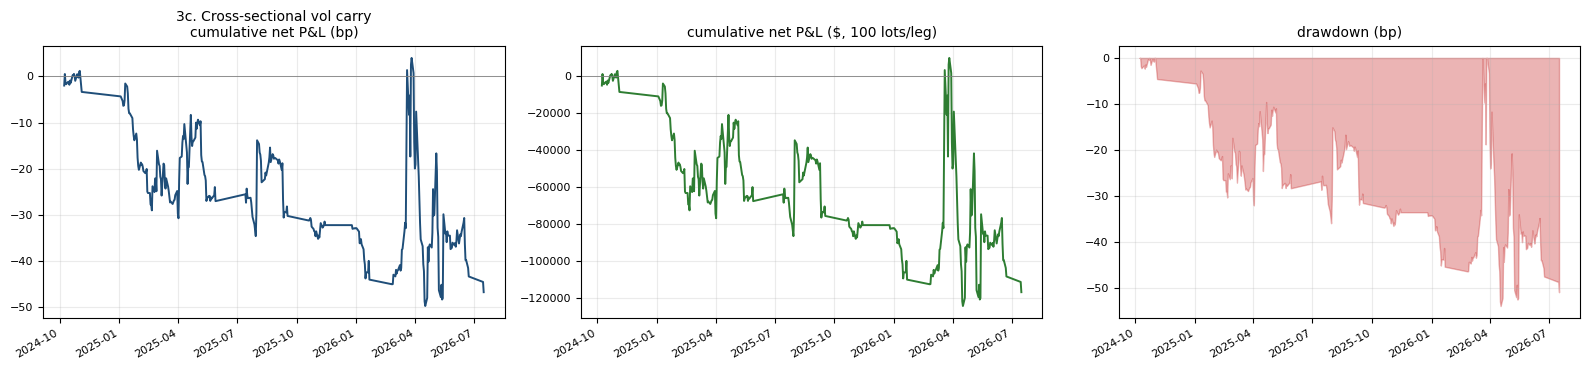


TRADE LOG (first rows)
   key  dir               structure signal_date      entry       exit  days   z_in  gross_bp  cost_bp   net_bp   net_usd  stale_frac  pkg_contracts exit_reason
SFRU25    1    straddle SFRU25@96.5  2024-10-04 2024-10-07 2024-11-04    20 -2.053   -0.8580      2.5  -3.3580  -8395.11         0.0            2.0        time
SFRU25    1      straddle SFRU25@96  2024-12-31 2025-01-02 2025-01-31    20 -2.062  -12.7285      2.5 -15.2285 -38071.35         0.0            2.0        time
SFRU26    1  straddle SFRU26@96.125  2025-01-27 2025-01-28 2025-02-25    20 -2.018   -2.0005      2.5  -4.5005 -11251.31         0.0            2.0        time
SFRM25   -1 straddle SFRM25@95.9375  2025-01-28 2025-01-29 2025-02-27    20  2.020   -2.2384      2.5  -4.7384 -11845.97         0.0            2.0        time
SFRZ25    1  straddle SFRZ25@95.875  2025-02-11 2025-02-12 2025-03-13    20 -2.007   -0.2716      2.5  -2.7716  -6929.07         0.0            2.0        time
SFRU25    1 stra

signal_source  lag  n_trades  total_gross_bp  total_net_bp  sharpe  hit_rate
       listed    0        41          49.491       -53.009  -0.751     0.463
       listed    1        40          53.179       -46.821  -0.638     0.450
same-bar (lag 0) gross inflation: -7.5%

  cost curve (round-trip bp charged on the package):
 round_trip_bp  n  total_net_bp  avg_net_bp  hit_rate  total_net_usd
           0.0 40        53.179       1.329     0.550      132947.25
           0.5 40        33.179       0.829     0.525       82947.25
           1.0 40        13.179       0.329     0.500       32947.25
           1.5 40        -6.821      -0.171     0.475      -17052.75
           2.5 40       -46.821      -1.171     0.450     -117052.75
           4.0 40      -106.821      -2.671     0.350     -267052.75

3c. Cross-sectional vol carry — median config (not selected)  |  fade|ma5|w60|z1.5|t10|lag1|every1|dh  |  100 contracts/leg ($2,500/bp)
  1 package = 2 contracts -> position = 200 contracts a

In [11]:
sig_xs = sig_vrp.copy()
sig_xs["signal"] = sig_xs.groupby("as_of")["vrp_bp"].transform(
    lambda s: s - s.mean())
out_xs = run_framework(
    "3c. Cross-sectional vol carry", signals=sig_xs, book=lab["book"],
    builder=builder, base=BASE, grid_spec=GRID, params=PARAMS, cls="C",
    note="VRP demeaned across contracts each date")

## Benchmark row for the league table

In [12]:
# The benchmark has NO fitted parameters — the only search is over 6 published
# variants (2 sides x 3 holds), so that is the honest n_trials for its DSR.
for _, row in bench.sort_values("total_net_bp", ascending=False).iterrows():
    cfg_b = dataclasses.replace(
        BASE, entry_rule="always", exit_style=row["hold"], entry_every=5,
        direction="fade" if row["side"] == "short" else "momentum")
    res_b = run_backtest(cfg_b, signals=sig_vrp, book=lab["book"], builder=builder)
    header_block(f"3d. Unconditional gamma — {row['side']} {row['hold']}",
                 res_b, grid=bench)
    league_row("3d. Unconditional gamma (benchmark)",
               f"{row['side']}-{row['hold']}", res_b, grid=bench, cls="C",
               note="NO signal and no fitted parameter — the number every vol "
                    "rule must beat")

3d. Unconditional gamma — short t20  |  fade|ma5|w120|z2.0|t20|lag1|every5|always|dh  |  100 contracts/leg ($2,500/bp)
  1 package = 2 contracts -> position = 200 contracts across all legs
  trades   152   skipped    0   hit 44%   avg -1.594bp   avg hold 19.1d   stale 0.0%
  total    -242.35bp   $    -605,875   gross +137.65bp
  daily-MTM Sharpe -0.73   maxDD -340.25bp ($-850,624)   worst trade -44.08bp
  t(trade) -2.24   NW t(daily) -1.03   non-overlap SR -0.14   DSR p=0.000 over 6 trials

  LEAGUE ROW  3d. Unconditional gamma (benchmark) / short-t20: MARGINAL-maker-only  (taker -242.35bp, maker +137.65bp, DSR p=0.000)
3d. Unconditional gamma — long t20  |  momentum|ma5|w120|z2.0|t20|lag1|every5|always|dh  |  100 contracts/leg ($2,500/bp)
  1 package = 2 contracts -> position = 200 contracts across all legs
  trades   152   skipped    0   hit 26%   avg -3.846bp   avg hold 19.1d   stale 0.0%
  total    -584.65bp   $  -1,461,624   gross -204.65bp
  daily-MTM Sharpe -1.82   maxDD -621.25


  LEAGUE ROW  3d. Unconditional gamma (benchmark) / long-t20: DEAD  (taker -584.65bp, maker -204.65bp, DSR p=0.000)
3d. Unconditional gamma — short t10  |  fade|ma5|w120|z2.0|t10|lag1|every5|always|dh  |  100 contracts/leg ($2,500/bp)
  1 package = 2 contracts -> position = 200 contracts across all legs
  trades   247   skipped    0   hit 29%   avg -2.551bp   avg hold 9.8d   stale 0.0%
  total    -630.00bp   $  -1,575,006   gross -12.50bp
  daily-MTM Sharpe -2.10   maxDD -636.83bp ($-1,592,068)   worst trade -30.55bp
  t(trade) -7.08   NW t(daily) -3.07   non-overlap SR -0.51   DSR p=0.000 over 6 trials

  LEAGUE ROW  3d. Unconditional gamma (benchmark) / short-t10: DEAD  (taker -630.00bp, maker -12.50bp, DSR p=0.000)
3d. Unconditional gamma — long t10  |  momentum|ma5|w120|z2.0|t10|lag1|every5|always|dh  |  100 contracts/leg ($2,500/bp)
  1 package = 2 contracts -> position = 200 contracts across all legs
  trades   247   skipped    0   hit 28%   avg -2.704bp   avg hold 9.8d   stale 


  LEAGUE ROW  3d. Unconditional gamma (benchmark) / long-t10: DEAD  (taker -667.78bp, maker -50.28bp, DSR p=0.000)
3d. Unconditional gamma — long t5  |  momentum|ma5|w120|z2.0|t5|lag1|every5|always|dh  |  100 contracts/leg ($2,500/bp)
  1 package = 2 contracts -> position = 200 contracts across all legs
  trades   365   skipped    0   hit 23%   avg -2.059bp   avg hold 5.0d   stale 0.0%
  total    -751.63bp   $  -1,879,072   gross +160.87bp
  daily-MTM Sharpe -3.01   maxDD -792.04bp ($-1,980,102)   worst trade -18.03bp
  t(trade) -8.52   NW t(daily) -3.94   non-overlap SR -0.56   DSR p=0.000 over 6 trials



  LEAGUE ROW  3d. Unconditional gamma (benchmark) / long-t5: MARGINAL-maker-only  (taker -751.63bp, maker +160.87bp, DSR p=0.000)
3d. Unconditional gamma — short t5  |  fade|ma5|w120|z2.0|t5|lag1|every5|always|dh  |  100 contracts/leg ($2,500/bp)
  1 package = 2 contracts -> position = 200 contracts across all legs
  trades   365   skipped    0   hit 19%   avg -3.085bp   avg hold 5.0d   stale 0.0%
  total   -1126.02bp   $  -2,815,045   gross -213.52bp
  daily-MTM Sharpe -4.16   maxDD -1132.84bp ($-2,832,107)   worst trade -21.35bp
  t(trade) -12.67   NW t(daily) -5.66   non-overlap SR -0.64   DSR p=0.000 over 6 trials

  LEAGUE ROW  3d. Unconditional gamma (benchmark) / short-t5: DEAD  (taker -1126.02bp, maker -213.52bp, DSR p=0.000)


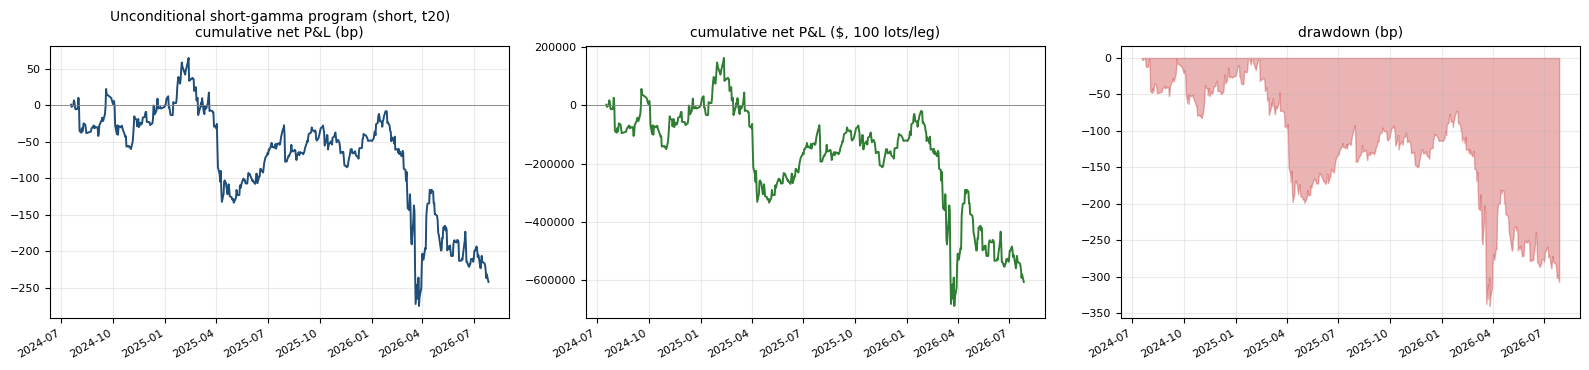


TRADE LOG
   key  dir               structure signal_date      entry       exit  days   z_in  gross_bp  cost_bp   net_bp   net_usd  stale_frac  pkg_contracts exit_reason
SFRH25   -1   straddle SFRH25@95.75  2024-07-16 2024-07-17 2024-08-14    20    NaN  -12.8362      2.5 -15.3362 -38340.60         0.0            2.0        time
SFRM26   -1    straddle SFRM26@96.5  2024-07-16 2024-07-17 2024-08-14    20    NaN    1.1232      2.5  -1.3768  -3442.12         0.0            2.0        time
SFRM25   -1 straddle SFRM25@96.0625  2024-07-16 2024-07-17 2024-08-14    20    NaN   -6.7660      2.5  -9.2660 -23164.91         0.0            2.0        time
SFRZ25   -1  straddle SFRZ25@96.375  2024-07-16 2024-07-17 2024-08-14    20    NaN   -0.2539      2.5  -2.7539  -6884.73         0.0            2.0        time
SFRH26   -1    straddle SFRH26@96.5  2024-07-16 2024-07-17 2024-08-14    20    NaN   -0.6789      2.5  -3.1789  -7947.18         0.0            2.0        time
SFRU25   -1   straddle SFRU25

,round_trip_bp,n,total_net_bp,avg_net_bp,hit_rate,total_net_usd
0,0.0,152,137.6501,0.905593,0.585526,344125.25
1,0.5,152,61.6501,0.405593,0.559211,154125.25
2,1.0,152,-14.3499,-0.094407,0.552632,-35874.75
3,1.5,152,-90.3499,-0.594407,0.526316,-225874.75
4,2.5,152,-242.3499,-1.594407,0.440789,-605874.75
5,4.0,152,-470.3499,-3.094407,0.375000,-1175874.75


In [13]:
best_bench = bench.sort_values("total_net_bp", ascending=False).iloc[0]
cfg_b = dataclasses.replace(
    BASE, entry_rule="always", exit_style=best_bench["hold"], entry_every=5,
    direction="fade" if best_bench["side"] == "short" else "momentum")
res_b = run_backtest(cfg_b, signals=sig_vrp, book=lab["book"], builder=builder)
if not res_b.daily_bp.empty:
    three_panel_equity(res_b, "Unconditional short-gamma program "
                              f"({best_bench['side']}, {best_bench['hold']})")
    plt.show()
print("\nTRADE LOG")
print(res_b.trades.sort_values("entry").head(30).to_string(index=False))
print("\nCOST CURVE — the benchmark's sensitivity to execution")
cost_block(res_b)